# Localization Analysis

## Introduction

This analysis focuses on evaluating the performance of the robot localization system using data obtained from several simulation scenarios.  
For each scenario and run, the real position and orientation of the robot are compared to the estimated ones provided by the **Nav2 localization module**, which relies on LiDAR-based 2D pose estimation in ROS2.

The objective is to understand the behavior of the localization system, identify possible sources of error, and analyze the consistency and accuracy of the estimated pose throughout the robot’s trajectory.

---

## Methodology

For every scenario, the CSV files are processed to extract:

- **Real position and orientation** of the robot.
- **Estimated position and orientation** from Nav2 (based on LiDAR and the map).
- **Covariance matrix** associated with the estimated pose.

From these data, the following metrics are computed:

1. **Vectorial position error**:  
   The Euclidean distance between the real and estimated positions at each timestamp.

2. **Orientation error**:  
   The angular difference between the real and estimated yaw angles.

3. **Dispersion (Uncertainty)**:  
   - For position: the determinant of the top-left 2×2 submatrix of the covariance matrix (`[0:2, 0:2]`), which reflects the uncertainty in the estimated (x, y) position.  
   - For orientation: the variance of the yaw angle, given by element `[5,5]` of the covariance matrix.

Each scenario is analyzed independently, focusing on how the position and orientation errors evolve over time and how they relate to the estimated dispersion.  

Finally, the behavior across scenarios is compared, although this comparison provides limited insight due to the high scenario-specific nature of localization uncertainty.

---

## Data Preprocessing Steps
1. Load CSV logs (amcl_pose, groundtruth_pose, tf, etc.) using Pandas.
2. Clean data: remove missing timestamps, align AMCL and ground truth messages by closest timestamp.
3. Compute position/orientation error and covariance determinants.
4. Aggregate data per scenario and run.
5. Visualize temporal evolution of error and dispersion.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [53]:
# GLOBAL VARIABLES
DATASET_CSV_PATH = "../data/sample_dataset_csv"

#NAMES COLUMNS
TIMESTAMP = 'timestamp'
TOPIC = 'topic'
TYPE = 'type'
POSE_FROM_COV = "pose.pose."
POSITION_X = "position.x"
POSITION_Y = "position.y"
ORIENTATION_Z = 'orientation.z'
ORIENTATION_W = 'orientation.w'
COVARIANCE = "pose.covariance"

#TOPICS
AMCL_POSE = '/amcl_pose'
GROUNDTRUTH_POSE = '/groundtruth_pose'


In [54]:
# Class with the data of a ros iteration
class DatasetRos:
    def __init__(self, scenario, run_n, csv_file):
        self.scenario = scenario
        self.run_n = run_n
        self.csv_file = csv_file
        self.df = pd.read_csv(
            csv_file,
            comment='#',       
            sep=',',           
            quotechar='"',     
            engine='python'
        )
#Quaternion for 2D orentation to yaw
def quaternion_to_yaw(z, w):
    return np.arctan2(2*w*z, 1 - 2*z**2)

# Get Pose error of the scenario (2D) in form of position_error, yaw_error, timestamp
# given deduced pose info and real pose info
def get_pose_error(deduced_pose, real_pose):
    #since is 2D just take position.x and y and orientation.z and w.
    deduced_position_x = deduced_pose[POSE_FROM_COV + POSITION_X].to_numpy()
    deduced_position_y = deduced_pose[POSE_FROM_COV + POSITION_Y].to_numpy()
    deduced_orientation_z = deduced_pose[POSE_FROM_COV + ORIENTATION_Z].to_numpy()
    deduced_orientation_w = deduced_pose[POSE_FROM_COV + ORIENTATION_W].to_numpy()
    deduced_timestamp = deduced_pose[TIMESTAMP].to_numpy()

    real_position_x = real_pose[POSITION_X].to_numpy()
    real_position_y = real_pose[POSITION_Y].to_numpy()
    real_orientation_z = real_pose[ORIENTATION_Z].to_numpy()
    real_orientation_w = real_pose[ORIENTATION_W].to_numpy()
    real_timestamp = real_pose[TIMESTAMP].to_numpy()
    
    #get interpolation of real_pose to timestamp of deduced_pose.
    real_position_x_inter = np.interp(deduced_timestamp, real_timestamp, real_position_x)
    real_position_y_inter = np.interp(deduced_timestamp, real_timestamp, real_position_y)
    real_orientation_z_inter = np.interp(deduced_timestamp, real_timestamp, real_orientation_z)
    real_orientation_w_inter = np.interp(deduced_timestamp, real_timestamp, real_orientation_w)

    #now it is possible to get the vectoriced error
    dx = deduced_position_x - real_position_x_inter
    dy = deduced_position_y - real_position_y_inter
    position_error = np.sqrt(dx**2 + dy**2)
    
    #get yaw error.
    real_yaw_inter = quaternion_to_yaw(real_orientation_z_inter, real_orientation_w_inter)
    deduced_yaw = quaternion_to_yaw(deduced_orientation_z, deduced_orientation_w)
    yaw_error = deduced_yaw - real_yaw_inter
    #normalice between [-pi, pi]
    yaw_error = (yaw_error + np.pi) % (2 * np.pi) - np.pi

    return position_error, yaw_error, deduced_timestamp

# Get dispersion of the position and orientation (2D) and  from deduced pose rows in form disp_pos, disp_yaw, timestamp
def get_disp_covariance(deduced_pose):
    disp_poss = []
    disp_yaws = []
    covariances_str = deduced_pose[COVARIANCE].to_numpy()
    timestamp = deduced_pose[TIMESTAMP].to_numpy()
    
    for covariance_str in covariances_str:
        #get the matrix from the string
        covariance = np.fromstring(covariance_str.replace('\n', ' ').replace('[', '').replace(']', ''), sep=' ')
        size = int(np.sqrt(len(covariance)))
        cov_matrix = covariance.reshape(size, size)
        
        disp_pos = np.linalg.det(cov_matrix[:2, :2])
        disp_yaw = cov_matrix[5,5]
        
        disp_poss.append(disp_pos)
        disp_yaws.append(disp_yaw)
    return disp_poss, disp_yaws, timestamp

cmap = plt.get_cmap('tab10')

In [55]:
#Get dataset
dataset = []

for csv_file in os.listdir(DATASET_CSV_PATH):
    if csv_file.endswith(".csv"):
        full_path = os.path.join(DATASET_CSV_PATH, csv_file)
        #Get map_name and run
        name = csv_file[:-4] #delete .csv
        name_parts = name.rsplit('-', 1)
        scenario = name_parts[0]
        run_n = int(name_parts[1])
        is_new_scenario = True
        #Group by scenarios
        for scenario_group in dataset:
            if scenario_group[0].scenario == scenario:
                scenario_group.append(DatasetRos(scenario, run_n, full_path))
                is_new_scenario = False
        if is_new_scenario:
            scenario_group = []
            scenario_group.append(DatasetRos(scenario, run_n, full_path))
            dataset.append(scenario_group)    

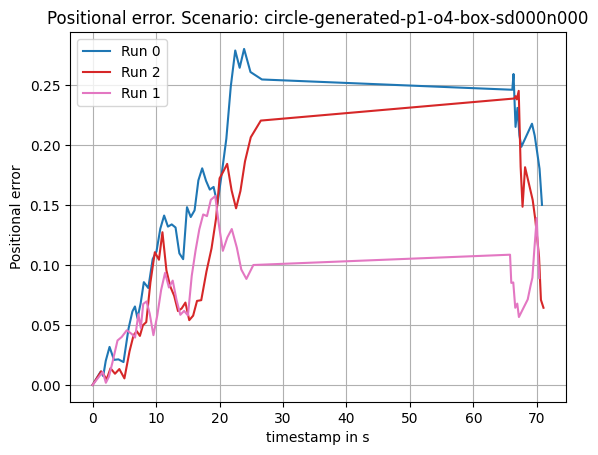

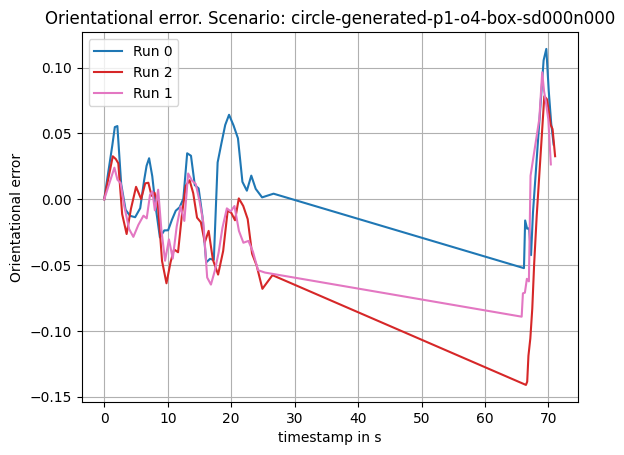

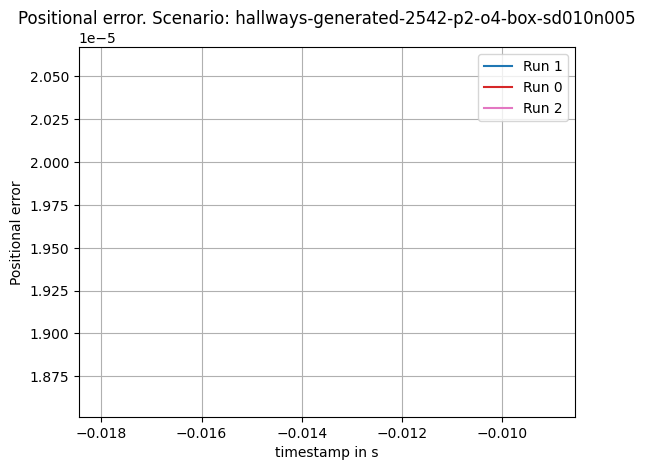

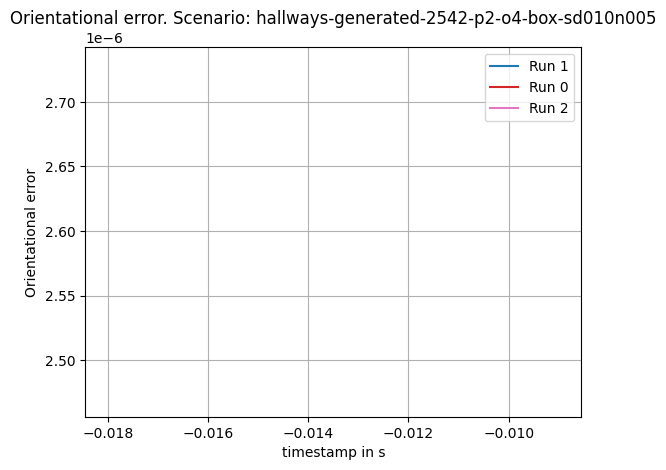

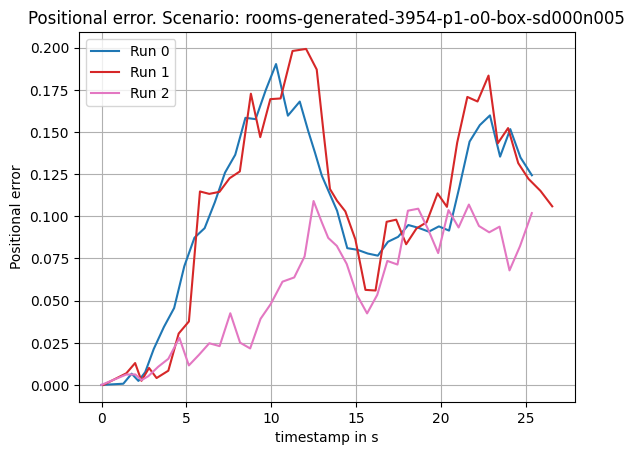

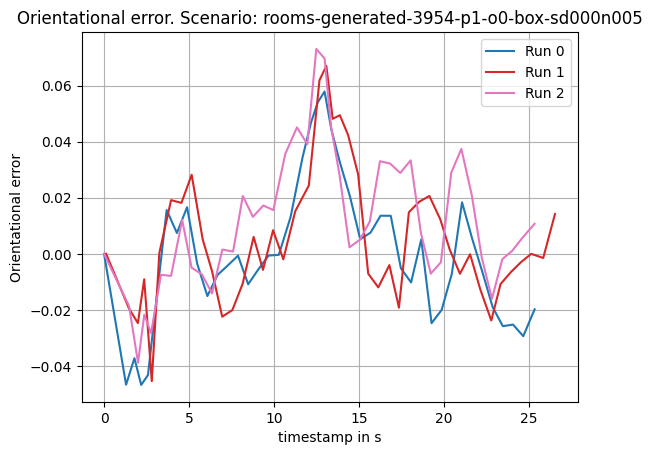

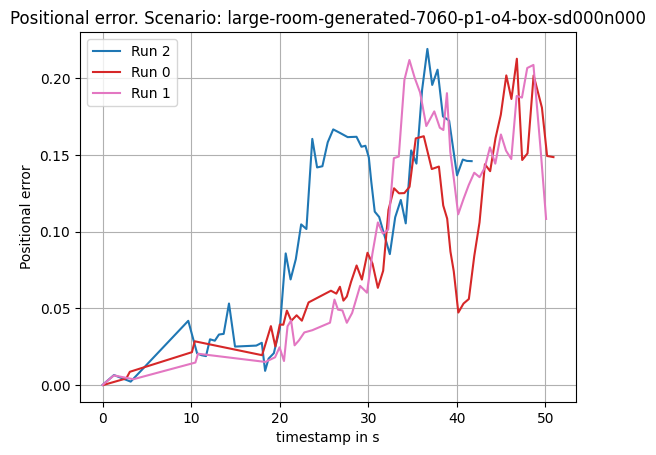

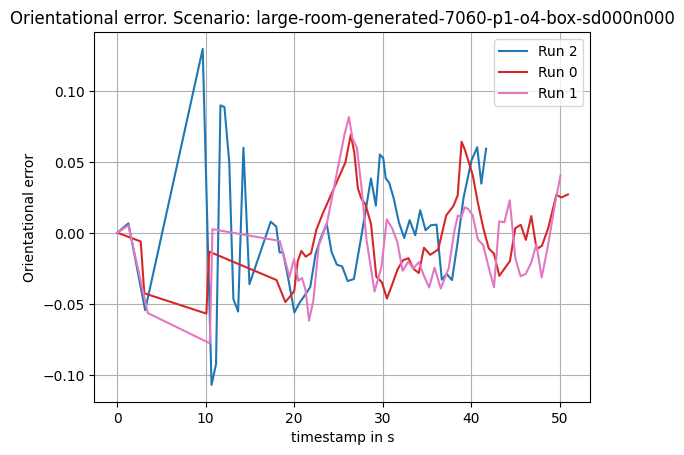

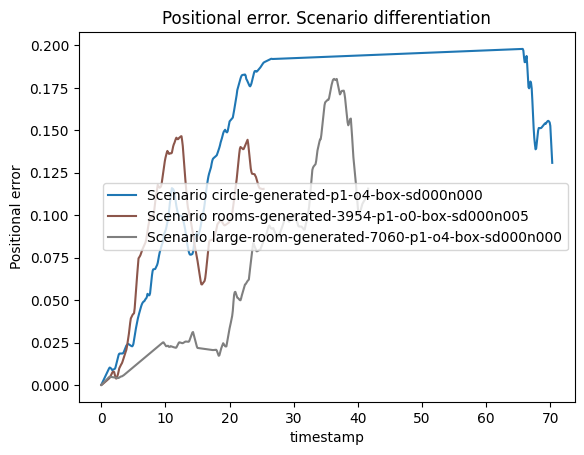

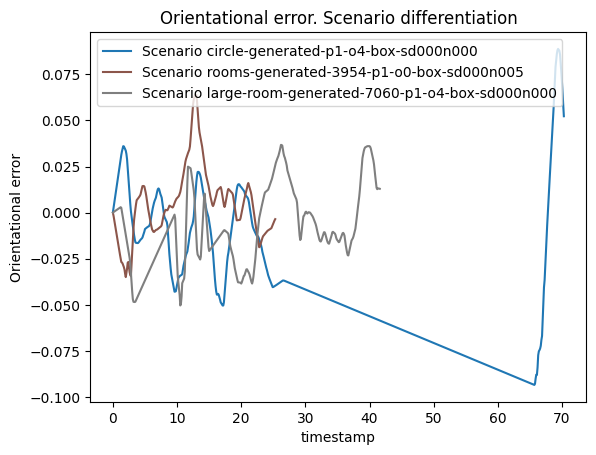

In [56]:
#Analysis of deduced pose with real pose (localization)

#figure for means position
plt.figure(0)
plt.title('Positional error. Scenario differentiation')
plt.xlabel(TIMESTAMP)
plt.ylabel('Positional error')
#figure for means orientation
plt.figure(1)
plt.title('Orientational error. Scenario differentiation')
plt.xlabel(TIMESTAMP)
plt.ylabel('Orientational error')

for i, scenario_group in enumerate(dataset):
    #first two for means, and we want two figures per scenario
    pos_f = 2 + i*2 
    or_f = 2 + i*2 + 1
    #figure for scenario position
    plt.figure(pos_f) 
    plt.title('Positional error. Scenario: ' +  scenario_group[0].scenario)
    plt.xlabel(TIMESTAMP + " in s")
    plt.ylabel('Positional error')
    #figure for scenario orientation
    plt.figure(or_f)
    plt.title('Orientational error. Scenario: ' +  scenario_group[0].scenario)
    plt.xlabel(TIMESTAMP + " in s")
    plt.ylabel('Orientational error')

    # maximum time of all runs and scenarios
    t_max = []
    # sum of position and orientation error of the scenario
    position_error_sum = []
    yaw_error_sum = []
              
    for j, run in enumerate(scenario_group):
        t0 = run.df[TIMESTAMP].iloc[1]
        deduced_pose = run.df.loc[run.df[TOPIC] == AMCL_POSE]
        real_pose = run.df.loc[run.df[TOPIC] == GROUNDTRUTH_POSE]

        # get pose error
        position_error, yaw_error, timestamp = get_pose_error(deduced_pose, real_pose)
        ts = np.asarray(timestamp - t0, dtype=np.float64) 
        ts = ts / 1e9 # time in seconds

        # Plot the data of the run in scenario differentiation
        color = cmap(j / len(scenario_group) )
        plt.figure(pos_f)
        plt.plot(ts, position_error, color=color, label=f"Run {run.run_n}")

        plt.figure(or_f)
        plt.plot(ts, yaw_error, color=color, label=f"Run {run.run_n}")   

        # mean of scenario:
        t_max.append(ts[-1])
        # array of time from 0 to max time each 0.1s to have common timeline
        t = np.arange(0, ts[-1], 0.1)
        position_error_sum.append(np.interp(t, ts, position_error))
        yaw_error_sum.append(np.interp(t, ts, yaw_error))

    plt.figure(pos_f)
    plt.grid()
    plt.legend()
    plt.figure(or_f)
    plt.grid()
    plt.legend()
    
    # Differentiate scenarios. Mean is just possible like this if all runs 
    # finish moreless the same time.
    t_mean = np.mean(t_max)
    t_std = np.std(t_max)
    if (abs(t_std / t_mean) < 0.1):
        # Create the mean of the scenarios 
        min_len = min(len(position_error) for position_error in position_error_sum)
        position_error_sum = [position_error[:min_len] for position_error in position_error_sum]
        yaw_error_sum = [yaw_error[:min_len] for yaw_error in yaw_error_sum]
        
        position_error_mean = np.mean(np.vstack(position_error_sum), axis=0)
        yaw_error_mean = np.mean(np.vstack(yaw_error_sum), axis=0)
        
        #get array of time until there is data of all runs
        t = np.arange(0, np.min(t_max), 0.1)
        #Plot results
        color = cmap(i / len(dataset) )
        plt.figure(0)
        plt.plot(t, position_error_mean, color=color, label=f"Scenario {scenario_group[0].scenario}")

        plt.figure(1)
        plt.plot(t, yaw_error_mean, color=color, label=f"Scenario {scenario_group[0].scenario}")   
        
plt.figure(0)
plt.legend()
plt.figure(1)
plt.legend()
    

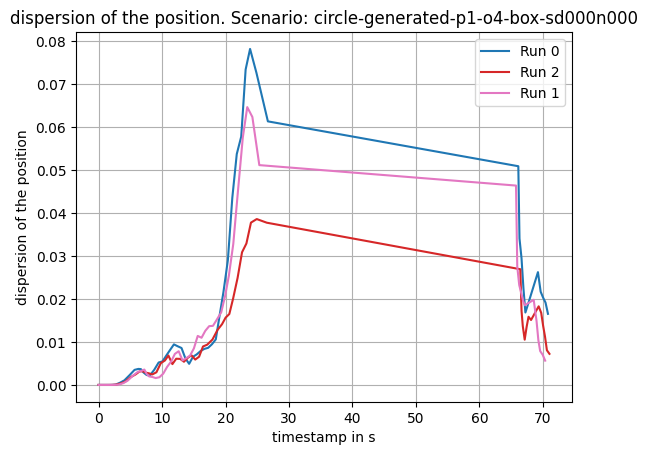

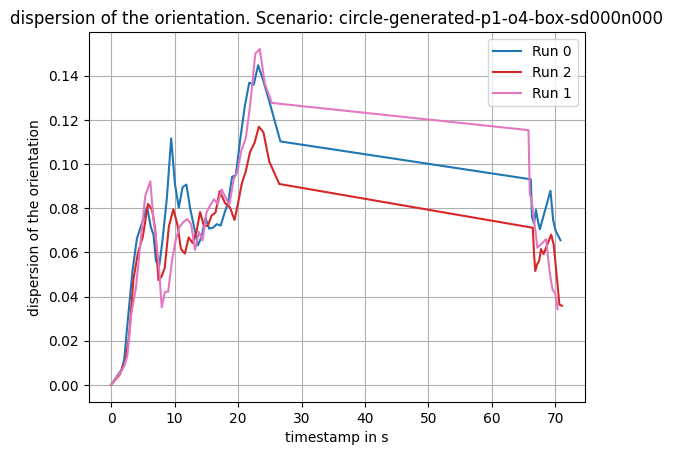

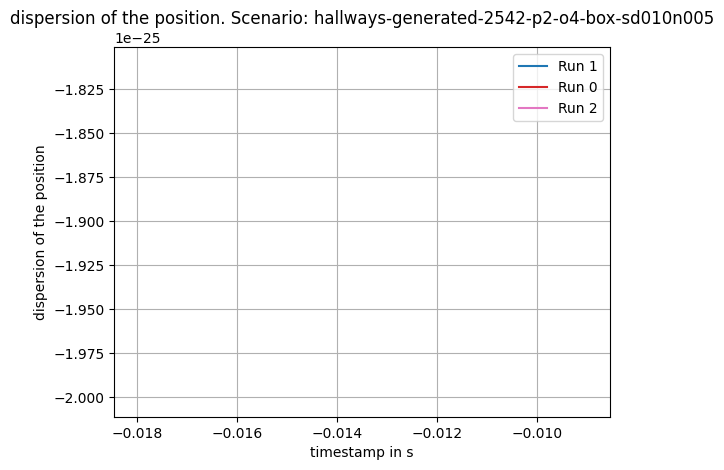

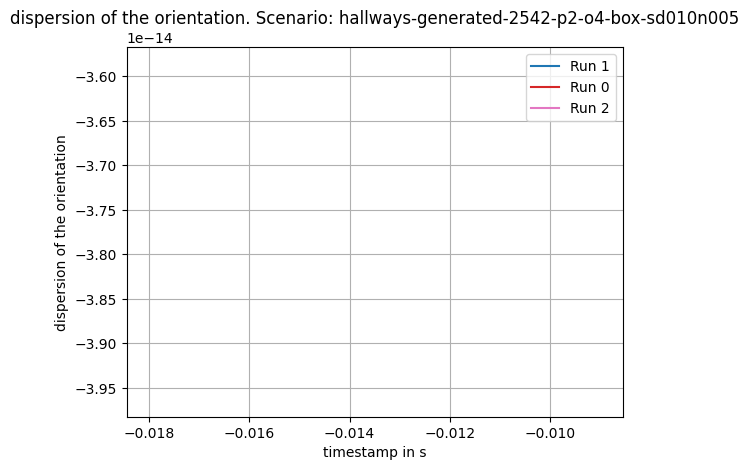

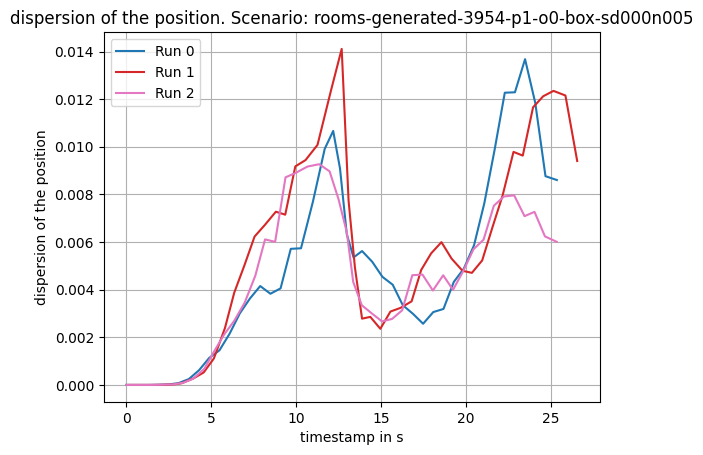

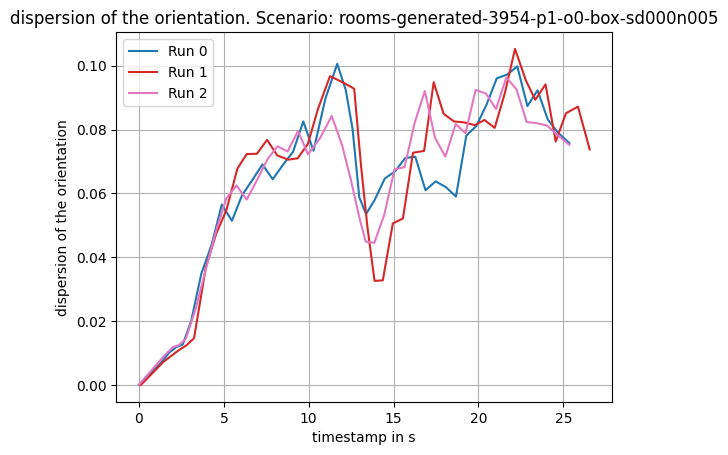

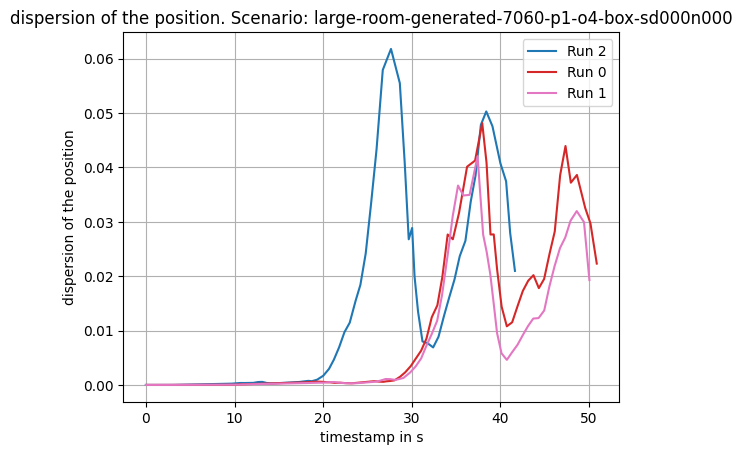

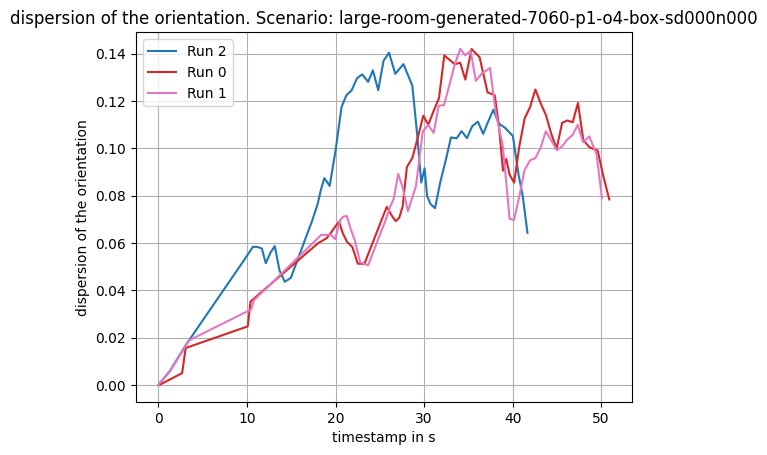

In [57]:
#Covariance analysis
#strong density equals small dispersion and good localization
#figure for means determinant covariance matrix

for i, scenario_group in enumerate(dataset):
    #we want two figure per scenario
    disp_pos_f = i*2
    disp_yaw_f = i*2 + 1
    #figures for dispersion of the position and orientation
    plt.figure(disp_pos_f) 
    plt.title('dispersion of the position. Scenario: ' +  scenario_group[0].scenario)
    plt.xlabel(TIMESTAMP + " in s")
    plt.ylabel('dispersion of the position')
        
    plt.figure(disp_yaw_f) 
    plt.title('dispersion of the orientation. Scenario: ' +  scenario_group[0].scenario)
    plt.xlabel(TIMESTAMP + " in s")
    plt.ylabel('dispersion of the orientation')
    

              
    for j, run in enumerate(scenario_group):
        t0 = run.df[TIMESTAMP].iloc[1]
        deduced_pose = run.df.loc[run.df[TOPIC] == AMCL_POSE]

        # get dispersion pose from covariance matrix
        disp_pos, disp_yaw, timestamp = get_disp_covariance(deduced_pose)
        ts = np.asarray(timestamp - t0, dtype=np.float64) 
        ts = ts / 1e9 # time in seconds

        # Plot the data of the run in scenario differentiation
        color = cmap(j / len(scenario_group) )
        plt.figure(disp_pos_f)
        plt.plot(ts, disp_pos, color=color, label=f"Run {run.run_n}")

        plt.figure(disp_yaw_f)
        plt.plot(ts, disp_yaw, color=color, label=f"Run {run.run_n}")

    plt.figure(disp_pos_f)
    plt.grid()
    plt.legend()
    plt.figure(disp_yaw_f)
    plt.grid()
    plt.legend()


## Scenario 1

In the first scenario, the graph shows how the robot’s localization error evolves over time.  
Initially, the error fluctuates until approximately **second 22**, where it becomes stable for a while before increasing again near the end of the run.

When compared with the dispersion data, a clear correlation is observed: around second 22, the dispersion increases sharply and remains high until the end.  
However, the position error does **not** increase during this period, indicating that despite a rise in uncertainty (lower confidence in localization), the **mean estimate remains close to the real position**.  
This behavior suggests that the localization system maintains good accuracy even when the confidence is low — a common situation when the robot moves through areas with similar geometric features that reduce the distinctiveness of LiDAR observations.

Additionally, small dispersion peaks can be observed when the robot encounters **local obstacles** not present in the map. These cause temporary inconsistencies between LiDAR readings and the known environment, resulting in transient uncertainty increases.

---

## Scenario 2

For the second scenario, **just one localization data were recorded**.  
The logs show that the system was unable to generate a valid path to the specified goal:

[component_container_isolated-9] [WARN] [1758736521.608117534] [planner_server]:
GridBased plugin failed to plan from (4.01, 4.78) to (5.29, -5.01):
"Failed to create plan with tolerance of: 0.500000"

[component_container_isolated-9] [ERROR] [1758736521.636280474] [bt_navigator]: Goal failed.

Because no trajectory could be executed, no localization or covariance data are available for analysis in this case.

---

## Scenario 3

In the third scenario, both the localization error and the dispersion increase steadily until approximately **second 15**, where they suddenly drop.  
This behavior corresponds to the robot reaching a **highly distinctive and identifiable position** within the map, allowing the localization system to recover its accuracy.

Although this map does not contain obstacles not represented in the map, the dispersion still increases gradually over time.  
This may be due to either:
- The **homogeneity of the environment**, where multiple regions share similar LiDAR features, or  
- **Sensor noise** in the LiDAR data.

To determine which factor dominates, additional sensor-level information would be required.

---

## Scenario 4

In the last scenario, clear peaks in both the **error** and **dispersion** can be observed simultaneously.  
Since there are no unmodeled obstacles, these peaks likely originate from either **localization ambiguity** in certain areas or **sensor issues**.

Given that the robot is located in unique regions of the map when these peaks occur, and the accompanying video evidence shows a temporary **misalignment between the LiDAR point cloud and the map** (appearing as if the LiDAR rotation drifts), the most plausible explanation is a **temporary LiDAR misreading** or **synchronization issue**.

To confirm this hypothesis, it would be necessary to directly compare the LiDAR scans with the expected global map data to check whether the deviation corresponds to sensor errors or environmental ambiguity. 

---

## Conclusions

Across all scenarios, the analysis of positional and orientational errors, together with covariance-based dispersion, provides valuable insight into the **stability and reliability of the Nav2 localization system**.  
The covariance determinant and yaw variance serve as effective indicators of uncertainty, complementing the error analysis by revealing moments of degraded localization confidence even when the average pose estimate remains accurate.

Further improvement of the analysis could include:
- Direct comparison between **LiDAR scan data** and the **global map**,  
- A **temporal correlation** study between navigation commands and uncertainty peaks, and
- Identify or classify unusual or failed runs 

### Future Improvements: Run Scoring System

As a possible extension of this work, a **scoring system** could be introduced to evaluate the overall performance of each navigation run.  
The idea is to assign a numerical score or percentage that reflects how well the robot performed in terms of localization and navigation.

The score could combine several key aspects, such as:

- **Localization accuracy:** based on the mean and maximum position and orientation errors, and the stability of the covariance determinant.  
- **Navigation success:** whether the robot successfully reached the goal and how close it was to the target position.  
- **Efficiency:** how long it took to reach the goal compared to an expected or optimal time, and how efficient the executed path was.  
- **Robustness:** the number of planner failures, collisions, or unlocalized intervals during the run.

Each of these components could be normalized between 0 and 1, then combined with specific weights to produce a **RunScore** between 0 (poor performance) and 1 (excellent performance).  
This would allow automatic classification of runs into *successful*, *degraded*, or *failed* categories, and make it easier to compare performance across scenarios.
 
Such a framework would help summarize results more objectively and enable automated detection of anomalies in large-scale experiments.